In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score 
from sklearn.metrics import precision_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
df=pd.read_csv("Loan_Prediction.csv")

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [7]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [23]:
df['Total_Income'].isnull().sum()

np.int64(0)

<Axes: xlabel='Loan_Status', ylabel='count'>

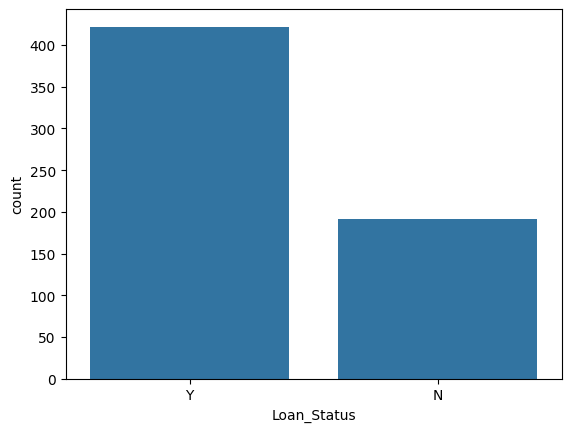

In [13]:
sns.countplot(x=df['Loan_Status'])

In [4]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome'] 

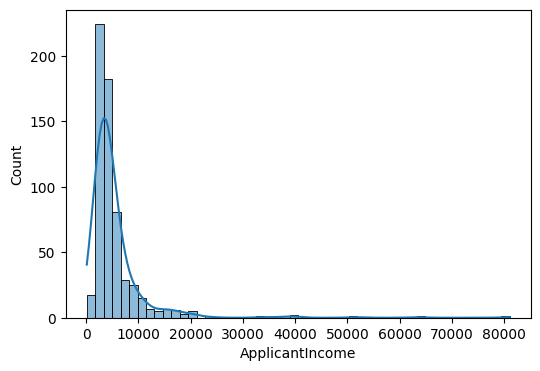

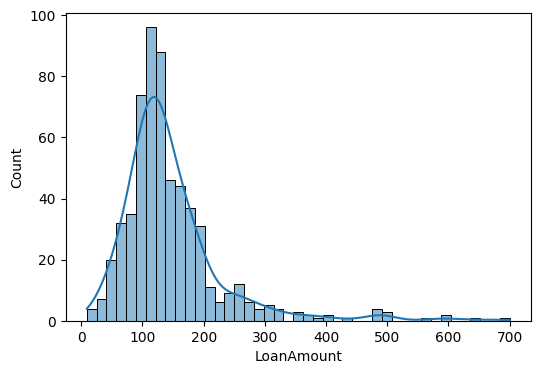

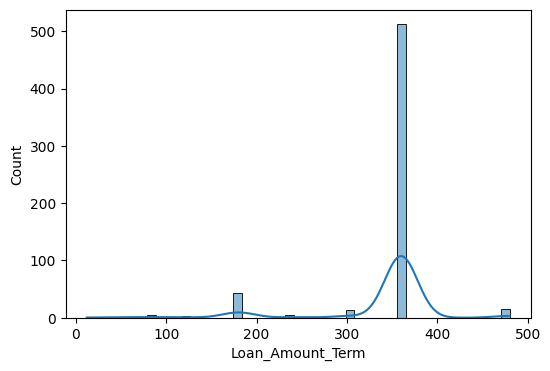

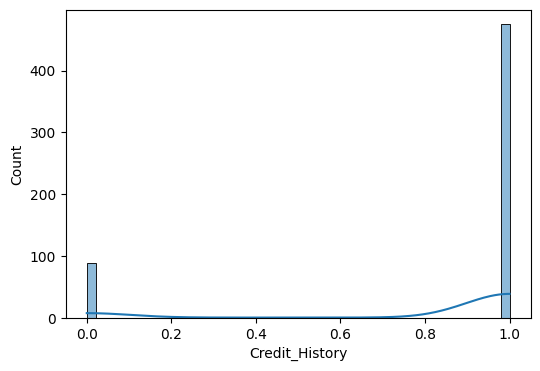

In [8]:
for column in Numerical_Columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[column],kde=True)
    plt.show()

In [15]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


<Axes: xlabel='Loan_Status', ylabel='Total_Income'>

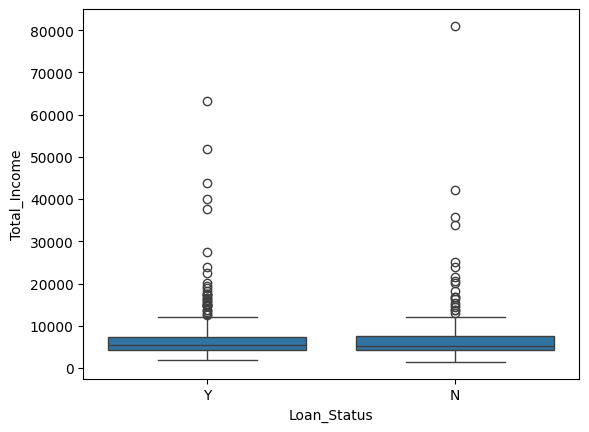

In [6]:
sns.boxplot(x='Loan_Status',y='Total_Income',data=df)

<Axes: xlabel='Loan_Status', ylabel='Total_Income'>

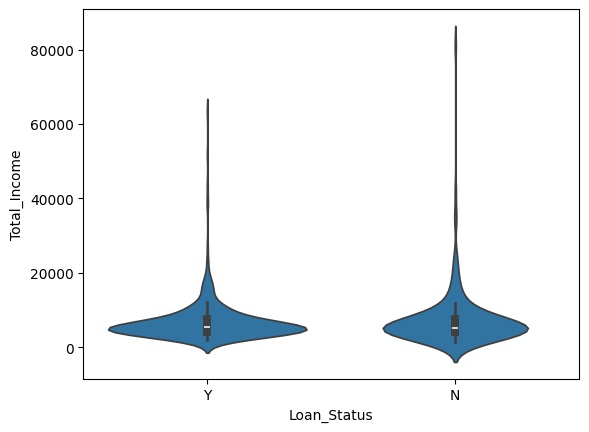

In [21]:
sns.violinplot(data=df, x='Loan_Status', y='Total_Income')

In [7]:
Numerical_Columns = ['ApplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']

In [25]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
Total_Income          0
dtype: int64

In [9]:
for column in Numerical_Columns:
    df[column] = df[column].fillna(df[column].median())
    

In [53]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income         0
dtype: int64

In [43]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900.0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106.0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8312.0
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583.0


In [10]:
Categorical_Columns = ['Gender','Married','Self_Employed','Dependents']

In [11]:
for column in Categorical_Columns:
    df[column] = df[column].fillna(df[column].mode()[0]) 

In [67]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0
610,LP002979,Male,Yes,3+,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0
611,LP002983,Male,Yes,1,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0
612,LP002984,Male,Yes,2,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0


In [12]:
numeric_cols = df.select_dtypes(include='number')
(numeric_cols.skew())

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.743053
Loan_Amount_Term    -2.402112
Credit_History      -2.021971
Total_Income         5.633449
dtype: float64

In [13]:
df=df.drop(columns=['ApplicantIncome','CoapplicantIncome'])

<Axes: xlabel='LoanAmount', ylabel='Count'>

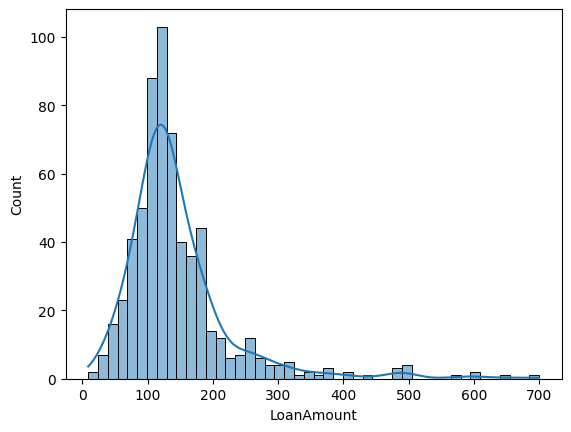

In [14]:
sns.histplot(df['LoanAmount'],kde=True)

<Axes: xlabel='Total_Income', ylabel='Count'>

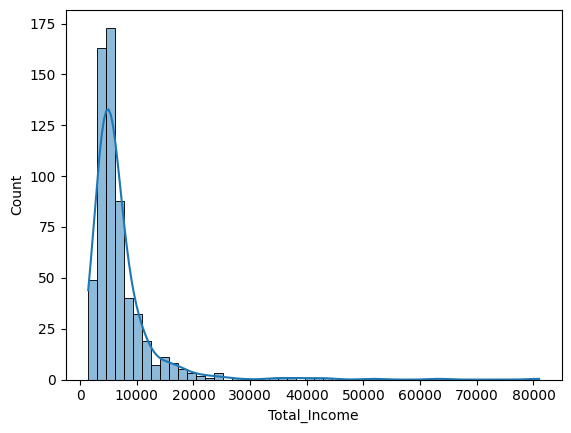

In [70]:
sns.histplot(df['Total_Income'],kde=True)

<Axes: xlabel='Credit_History', ylabel='Count'>

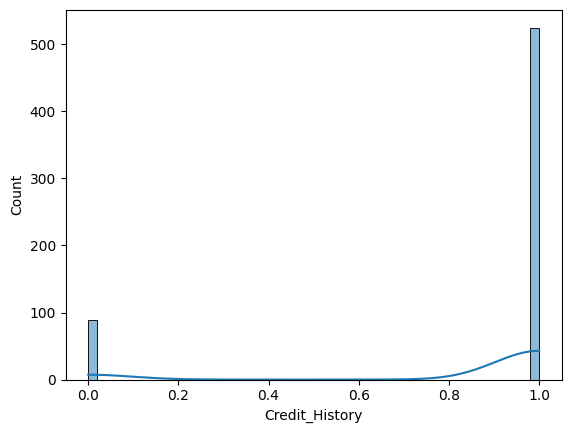

In [75]:
sns.histplot(df['Credit_History'],kde=True)

<Axes: xlabel='Credit_History', ylabel='count'>

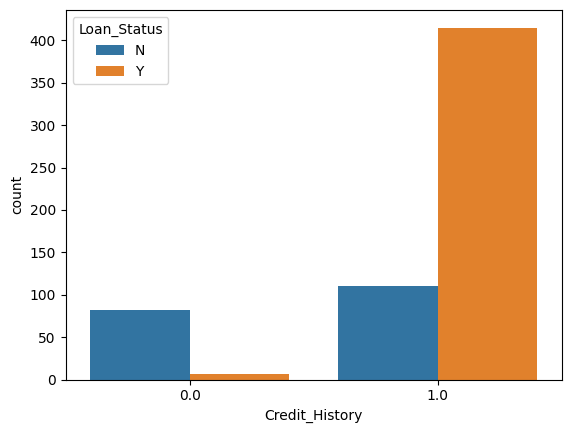

In [78]:
sns.countplot(x='Credit_History',data=df, hue = 'Loan_Status')

In [15]:
df['Log_Loan_amount'] = np.log1p(df['LoanAmount'])

<Axes: xlabel='LoanAmount', ylabel='Count'>

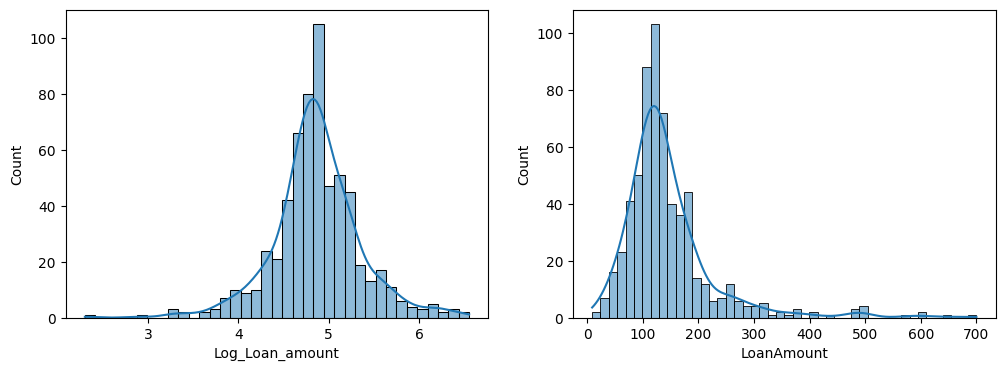

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Log_Loan_amount'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['LoanAmount'],kde=True)

In [83]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount
0,LP001002,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0,8.674197
1,LP001003,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0,8.505525
4,LP001008,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0,8.699681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0,7.972811
610,LP002979,Male,Yes,3+,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0,8.320448
611,LP002983,Male,Yes,1,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0,9.025576
612,LP002984,Male,Yes,2,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0,8.933796


In [17]:
df['Log_Total_Income'] = np.log1p(df['Total_Income'])

<Axes: xlabel='Total_Income', ylabel='Count'>

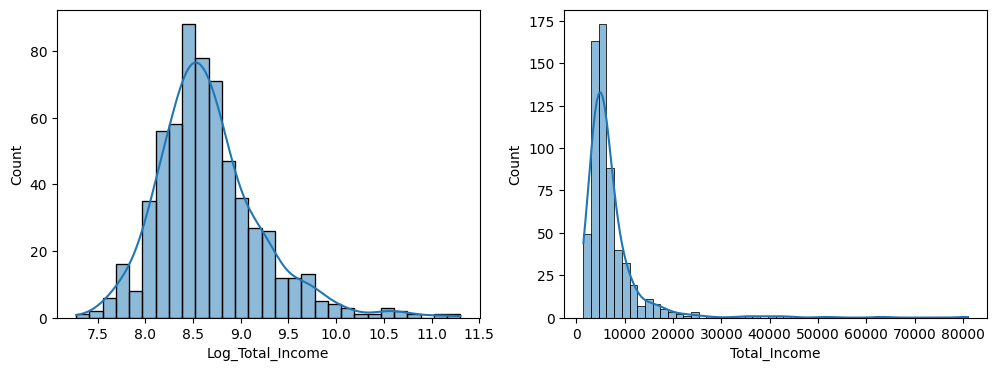

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Log_Total_Income'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['Total_Income'],kde=True)

In [19]:
df['Log_Loan_Amount_Term'] = np.log1p(df['Loan_Amount_Term'])

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

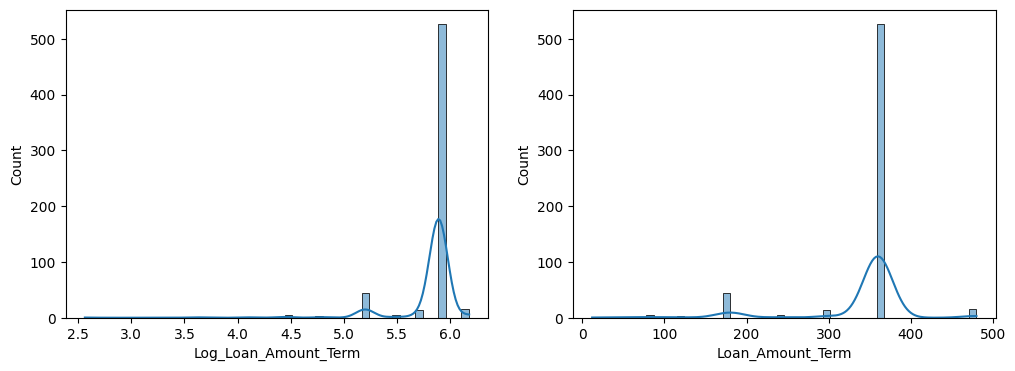

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Log_Loan_Amount_Term'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['Loan_Amount_Term'],kde=True)

In [21]:
df['Log_Credit_History'] = np.log1p(df['Credit_History'])

<Axes: xlabel='Credit_History', ylabel='Count'>

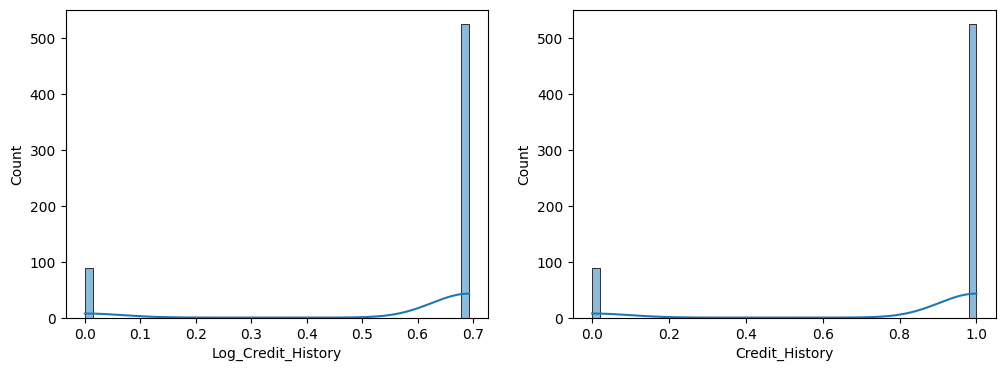

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['Log_Credit_History'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['Credit_History'],kde=True)

In [106]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History
0,LP001002,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0,4.859812,8.674197,5.888878,0.693147
1,LP001003,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0,4.859812,8.714732,5.888878,0.693147
2,LP001005,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0,4.204693,8.006701,5.888878,0.693147
3,LP001006,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0,4.795791,8.505525,5.888878,0.693147
4,LP001008,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0,4.955827,8.699681,5.888878,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0,4.276666,7.972811,5.888878,0.693147
610,LP002979,Male,Yes,3+,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0,3.713572,8.320448,5.198497,0.693147
611,LP002983,Male,Yes,1,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0,5.537334,9.025576,5.888878,0.693147
612,LP002984,Male,Yes,2,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0,5.236442,8.933796,5.888878,0.693147


In [108]:
df['Dependents'].unique()

<StringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str

In [112]:
df['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [23]:
df['Dependents'] = df['Dependents'].replace('3+',3).astype(float)

In [24]:
df['Dependents'].value_counts()

Dependents
0.0    360
1.0    102
2.0    101
3.0     51
Name: count, dtype: int64

In [129]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History,Monthly_Installment,Income_Loan_Ratio
0,LP001002,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,NaN,5849.0,4.859812,8.674197,5.888878,0.693147,16.247222,45.695312
1,LP001003,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,NaN,6091.0,4.859812,8.714732,5.888878,0.693147,16.919444,47.585938
2,LP001005,Male,Yes,0.0,Graduate,Yes,66.0,360.0,1.0,Urban,NaN,3000.0,4.204693,8.006701,5.888878,0.693147,8.333333,45.454545
3,LP001006,Male,Yes,0.0,Not Graduate,No,120.0,360.0,1.0,Urban,NaN,4941.0,4.795791,8.505525,5.888878,0.693147,13.725000,41.175000
4,LP001008,Male,No,0.0,Graduate,No,141.0,360.0,1.0,Urban,NaN,6000.0,4.955827,8.699681,5.888878,0.693147,16.666667,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,71.0,360.0,1.0,Rural,NaN,2900.0,4.276666,7.972811,5.888878,0.693147,8.055556,40.845070
610,LP002979,Male,Yes,3.0,Graduate,No,40.0,180.0,1.0,Rural,NaN,4106.0,3.713572,8.320448,5.198497,0.693147,22.811111,102.650000
611,LP002983,Male,Yes,1.0,Graduate,No,253.0,360.0,1.0,Urban,NaN,8312.0,5.537334,9.025576,5.888878,0.693147,23.088889,32.853755
612,LP002984,Male,Yes,2.0,Graduate,No,187.0,360.0,1.0,Urban,NaN,7583.0,5.236442,8.933796,5.888878,0.693147,21.063889,40.550802


In [25]:
df['Monthly_Installment'] = df['Total_Income'] / df['Loan_Amount_Term']
df['Income_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

In [26]:
df['Monthly_Installment']

0      16.247222
1      16.919444
2       8.333333
3      13.725000
4      16.666667
         ...    
609     8.055556
610    22.811111
611    23.088889
612    21.063889
613    12.730556
Name: Monthly_Installment, Length: 614, dtype: float64

In [28]:
df['Income_Loan_Ratio']

0       45.695312
1       47.585938
2       45.454545
3       41.175000
4       42.553191
          ...    
609     40.845070
610    102.650000
611     32.853755
612     40.550802
613     34.458647
Name: Income_Loan_Ratio, Length: 614, dtype: float64

In [27]:
df.isnull().sum()

Loan_ID                 0
Gender                  0
Married                 0
Dependents              0
Education               0
Self_Employed           0
LoanAmount              0
Loan_Amount_Term        0
Credit_History          0
Property_Area           0
Loan_Status             0
Total_Income            0
Log_Loan_amount         0
Log_Total_Income        0
Log_Loan_Amount_Term    0
Log_Credit_History      0
Monthly_Installment     0
Income_Loan_Ratio       0
dtype: int64

In [29]:
Cat_Cols = ['Gender','Married','Education','Self_Employed','Property_Area']

In [30]:
Cat_Cols

['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [31]:
df['Loan_Status'] = df['Loan_Status'].map({'N': 0  ,  'Y': 1})

In [32]:
df2 = pd.read_csv("Loan_Prediction.csv",usecols=['Loan_Status'])

In [135]:
df2

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y
...,...
609,Y
610,Y
611,Y
612,Y


In [33]:
df['Loan_Status']= df2['Loan_Status']

In [137]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History,Monthly_Installment,Income_Loan_Ratio
0,LP001002,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0,4.859812,8.674197,5.888878,0.693147,16.247222,45.695312
1,LP001003,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0,4.859812,8.714732,5.888878,0.693147,16.919444,47.585938
2,LP001005,Male,Yes,0.0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0,4.204693,8.006701,5.888878,0.693147,8.333333,45.454545
3,LP001006,Male,Yes,0.0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0,4.795791,8.505525,5.888878,0.693147,13.725000,41.175000
4,LP001008,Male,No,0.0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0,4.955827,8.699681,5.888878,0.693147,16.666667,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0,4.276666,7.972811,5.888878,0.693147,8.055556,40.845070
610,LP002979,Male,Yes,3.0,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0,3.713572,8.320448,5.198497,0.693147,22.811111,102.650000
611,LP002983,Male,Yes,1.0,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0,5.537334,9.025576,5.888878,0.693147,23.088889,32.853755
612,LP002984,Male,Yes,2.0,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0,5.236442,8.933796,5.888878,0.693147,21.063889,40.550802


In [34]:
Loan_Status= df2['Loan_Status']

In [35]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History,Monthly_Installment,Income_Loan_Ratio
0,LP001002,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0,4.859812,8.674197,5.888878,0.693147,16.247222,45.695312
1,LP001003,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0,4.859812,8.714732,5.888878,0.693147,16.919444,47.585938
2,LP001005,Male,Yes,0.0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0,4.204693,8.006701,5.888878,0.693147,8.333333,45.454545
3,LP001006,Male,Yes,0.0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0,4.795791,8.505525,5.888878,0.693147,13.725000,41.175000
4,LP001008,Male,No,0.0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0,4.955827,8.699681,5.888878,0.693147,16.666667,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,71.0,360.0,1.0,Rural,Y,2900.0,4.276666,7.972811,5.888878,0.693147,8.055556,40.845070
610,LP002979,Male,Yes,3.0,Graduate,No,40.0,180.0,1.0,Rural,Y,4106.0,3.713572,8.320448,5.198497,0.693147,22.811111,102.650000
611,LP002983,Male,Yes,1.0,Graduate,No,253.0,360.0,1.0,Urban,Y,8312.0,5.537334,9.025576,5.888878,0.693147,23.088889,32.853755
612,LP002984,Male,Yes,2.0,Graduate,No,187.0,360.0,1.0,Urban,Y,7583.0,5.236442,8.933796,5.888878,0.693147,21.063889,40.550802


In [36]:
df['Loan_Status'] = df['Loan_Status'].str.strip()

In [37]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,  'N':0})

In [38]:
df['Loan_Status']

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [144]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History,Monthly_Installment,Income_Loan_Ratio
0,LP001002,Male,No,0.0,Graduate,No,128.0,360.0,1.0,Urban,1,5849.0,4.859812,8.674197,5.888878,0.693147,16.247222,45.695312
1,LP001003,Male,Yes,1.0,Graduate,No,128.0,360.0,1.0,Rural,0,6091.0,4.859812,8.714732,5.888878,0.693147,16.919444,47.585938
2,LP001005,Male,Yes,0.0,Graduate,Yes,66.0,360.0,1.0,Urban,1,3000.0,4.204693,8.006701,5.888878,0.693147,8.333333,45.454545
3,LP001006,Male,Yes,0.0,Not Graduate,No,120.0,360.0,1.0,Urban,1,4941.0,4.795791,8.505525,5.888878,0.693147,13.725000,41.175000
4,LP001008,Male,No,0.0,Graduate,No,141.0,360.0,1.0,Urban,1,6000.0,4.955827,8.699681,5.888878,0.693147,16.666667,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,71.0,360.0,1.0,Rural,1,2900.0,4.276666,7.972811,5.888878,0.693147,8.055556,40.845070
610,LP002979,Male,Yes,3.0,Graduate,No,40.0,180.0,1.0,Rural,1,4106.0,3.713572,8.320448,5.198497,0.693147,22.811111,102.650000
611,LP002983,Male,Yes,1.0,Graduate,No,253.0,360.0,1.0,Urban,1,8312.0,5.537334,9.025576,5.888878,0.693147,23.088889,32.853755
612,LP002984,Male,Yes,2.0,Graduate,No,187.0,360.0,1.0,Urban,1,7583.0,5.236442,8.933796,5.888878,0.693147,21.063889,40.550802


In [39]:
df = df.drop(columns=['Loan_ID'])

In [40]:
df['Gender'] = df['Gender'] .map({'No': 0 , 'Yes':1})

In [41]:
df3=pd.read_csv("Loan_Prediction.csv")

In [42]:
df['Gender'] =df3['Gender']

In [43]:
df['Married'] =df3['Married']

In [44]:
df['Gender'] = df['Gender'].str.strip() 

Bhai jaan Female = 0 diya and male = 1

In [45]:
df['Gender'] = df['Gender'] .map({'Female': 0 , 'Male':1})

In [59]:
df

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Log_Loan_amount,Log_Total_Income,Log_Loan_Amount_Term,Log_Credit_History,Monthly_Installment,Income_Loan_Ratio
0,1.0,0.0,0.0,1,0,128.0,360.0,1.0,0,1,5849.0,4.859812,8.674197,5.888878,0.693147,16.247222,45.695312
1,1.0,1.0,1.0,1,0,128.0,360.0,1.0,1,0,6091.0,4.859812,8.714732,5.888878,0.693147,16.919444,47.585938
2,1.0,1.0,0.0,1,1,66.0,360.0,1.0,0,1,3000.0,4.204693,8.006701,5.888878,0.693147,8.333333,45.454545
3,1.0,1.0,0.0,0,0,120.0,360.0,1.0,0,1,4941.0,4.795791,8.505525,5.888878,0.693147,13.725000,41.175000
4,1.0,0.0,0.0,1,0,141.0,360.0,1.0,0,1,6000.0,4.955827,8.699681,5.888878,0.693147,16.666667,42.553191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,1,0,71.0,360.0,1.0,1,1,2900.0,4.276666,7.972811,5.888878,0.693147,8.055556,40.845070
610,1.0,1.0,3.0,1,0,40.0,180.0,1.0,1,1,4106.0,3.713572,8.320448,5.198497,0.693147,22.811111,102.650000
611,1.0,1.0,1.0,1,0,253.0,360.0,1.0,0,1,8312.0,5.537334,9.025576,5.888878,0.693147,23.088889,32.853755
612,1.0,1.0,2.0,1,0,187.0,360.0,1.0,0,1,7583.0,5.236442,8.933796,5.888878,0.693147,21.063889,40.550802


In [47]:
df['Married'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [48]:
df['Married'] = df['Married'].map({'Yes':1   ,  'No':0})

In [49]:
df['Education'].unique()

<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [50]:
df['Education'] = df['Education'].map({'Graduate' : 1  ,'Not Graduate' : 0})

In [51]:
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1  , 'No':0})

In [57]:
df.isnull().sum()

Gender                  0
Married                 0
Dependents              0
Education               0
Self_Employed           0
LoanAmount              0
Loan_Amount_Term        0
Credit_History          0
Property_Area           0
Loan_Status             0
Total_Income            0
Log_Loan_amount         0
Log_Total_Income        0
Log_Loan_Amount_Term    0
Log_Credit_History      0
Monthly_Installment     0
Income_Loan_Ratio       0
dtype: int64

In [53]:
df['Property_Area'].unique()

<StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

In [54]:
df['Property_Area']= df['Property_Area'].map({'Urban' : 0 , 'Rural':1 ,'Semiurban':2})

In [55]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [56]:
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

In [73]:
 Pipeline = Pipeline(steps=[
     ('Scaler' , StandardScaler()),
     ('LogisticRegression',LogisticRegression()),
 ]
                    )

In [74]:
Pipeline.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaler', ...), ('LogisticRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penaltie

In [69]:
x = df.drop( columns = ['Loan_Status'])
y = df['Loan_Status']

In [71]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,random_state=42, test_size= 0.2)

In [76]:
Y_pred = Pipeline.predict(X_test)

In [83]:
accuracy_score(Y_test,Y_pred)*100

78.04878048780488

In [85]:
classification_report(Y_test,Y_pred)

'              precision    recall  f1-score   support\n\n           0       0.90      0.42      0.57        43\n           1       0.76      0.97      0.85        80\n\n    accuracy                           0.78       123\n   macro avg       0.83      0.70      0.71       123\nweighted avg       0.81      0.78      0.75       123\n'

In [88]:
confusion_matrix(Y_test,Y_pred)

array([[18, 25],
       [ 2, 78]])

In [94]:
precision_score(Y_test,Y_pred)*100

75.72815533980582

In [93]:
recall_score(Y_test,Y_pred)*100

97.5

In [95]:
print(df['Loan_Status'].value_counts(normalize=True))  #  for percentage

Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


In [99]:
Pipeline_RFC = Pipeline(steps=[
    ('Scaling' , StandardScaler()),
    ('Strategy',RandomForestClassifier(n_estimators=100,random_state = 42)),
])   

In [100]:
Pipeline_RFC.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaling', ...), ('Strategy', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [102]:
RFC_pred = Pipeline_RFC.predict(X_test)

In [106]:
accuracy_score(Y_test,RFC_pred)*100

78.86178861788618

In [107]:
confusion_matrix(Y_test,RFC_pred)

array([[23, 20],
       [ 6, 74]])